<a href="https://colab.research.google.com/github/fauziah-azzhr/PertemuanKesembilan/blob/main/Pertemuan9LatihanPraktikum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PRAKTIKUM 9.1: PERBANDINGAN TEKNIK THRESHOLDING


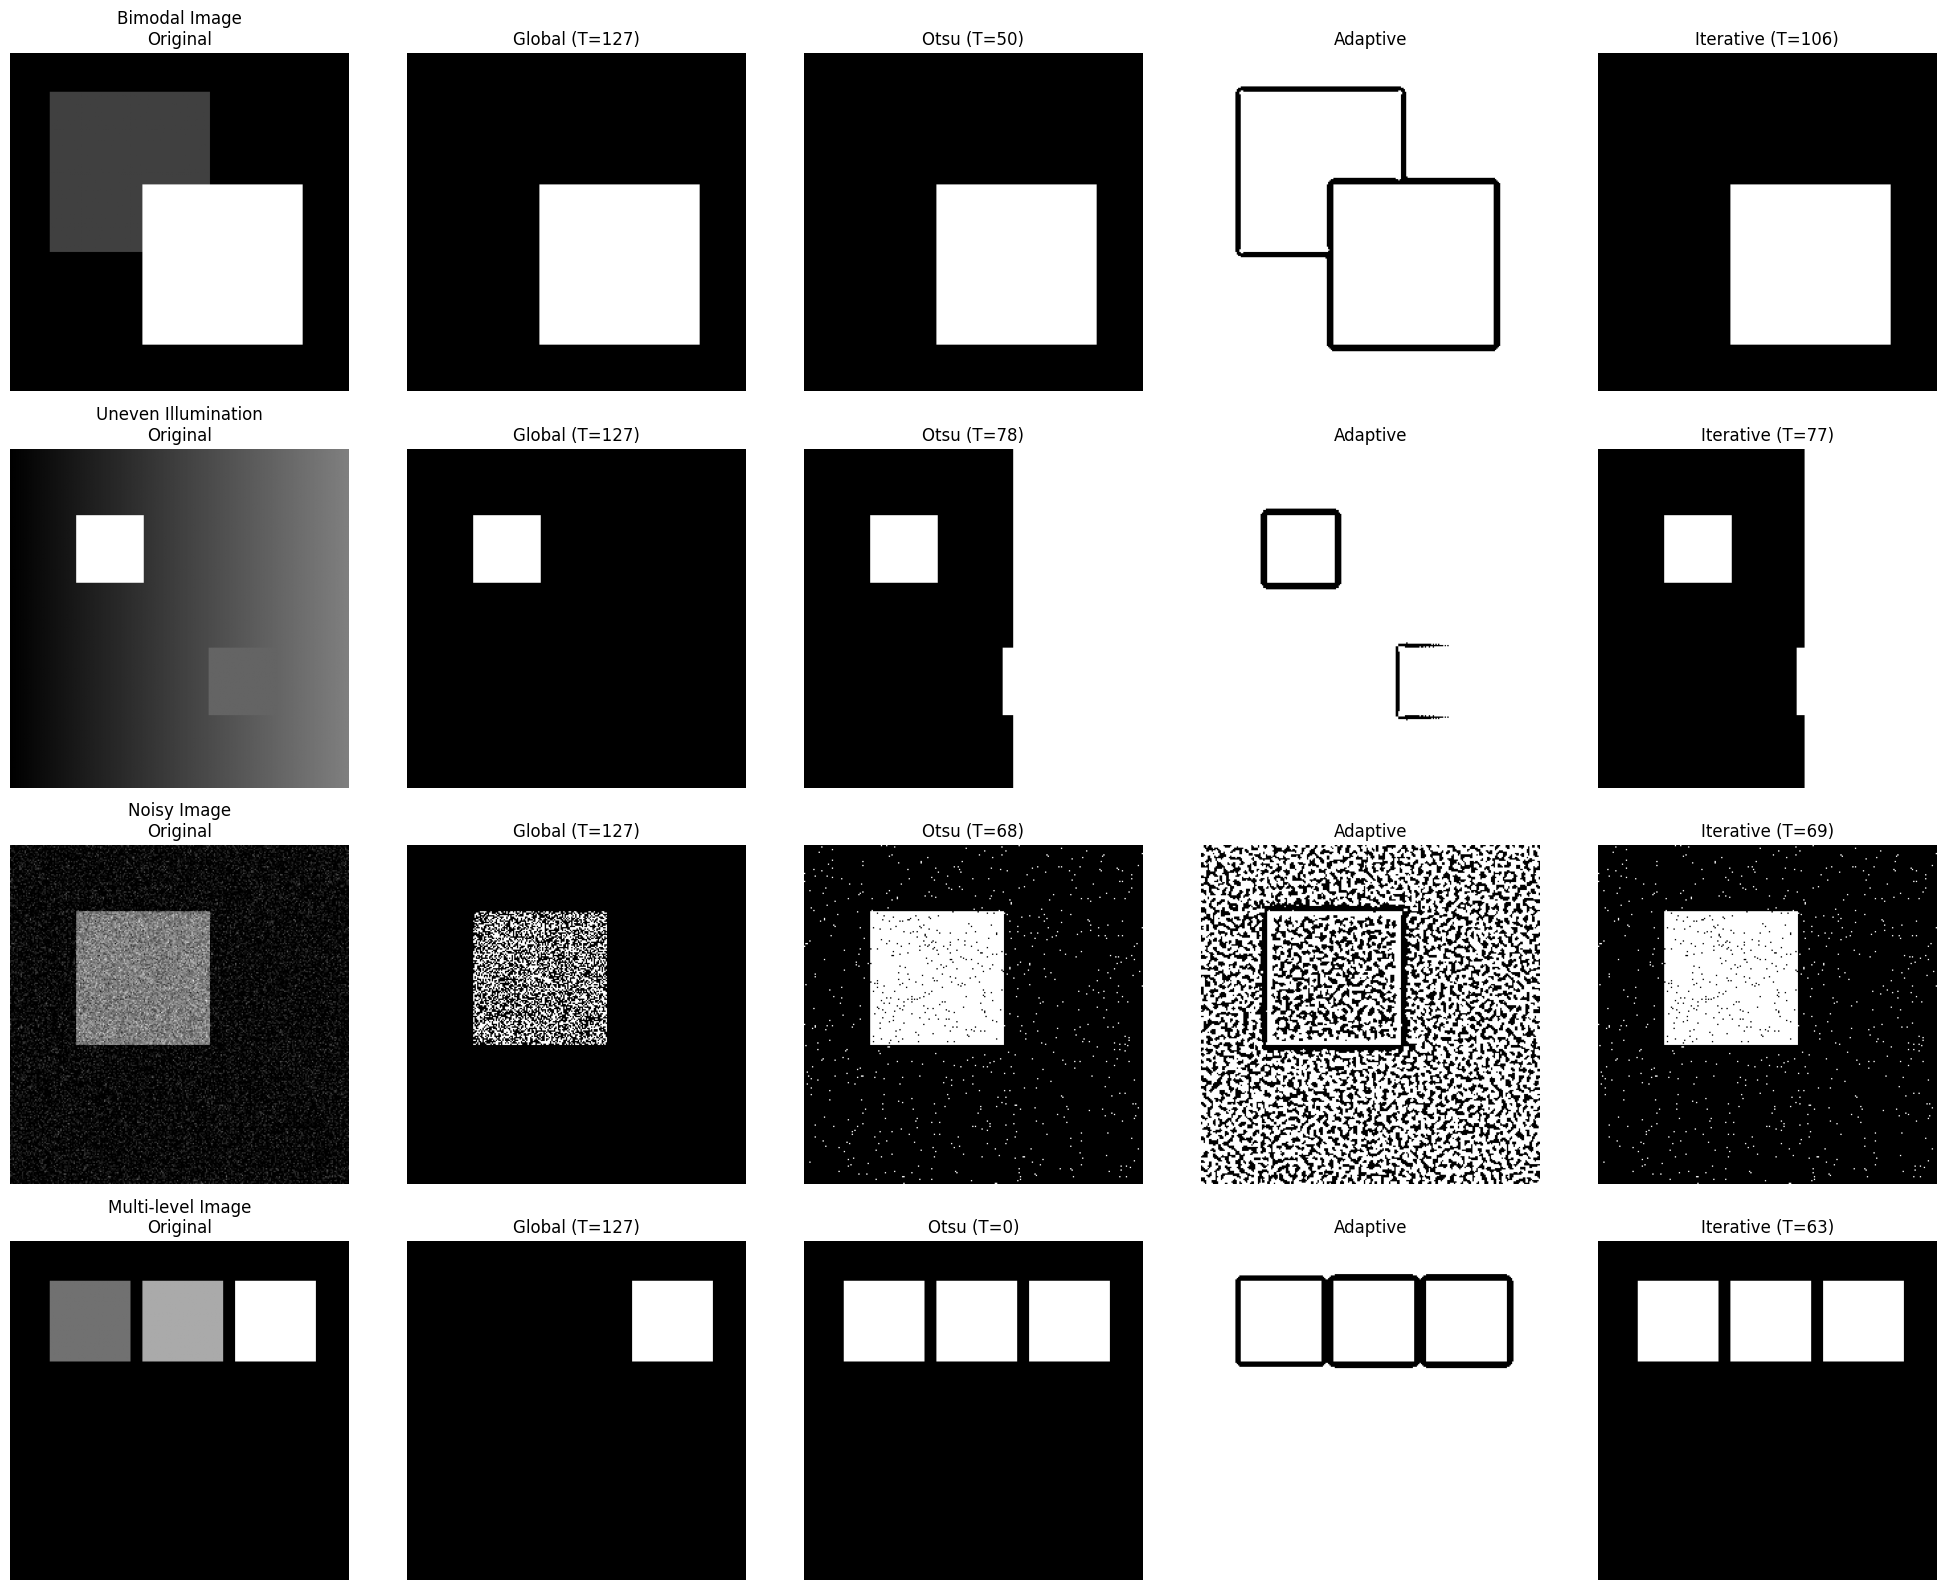


ANALISIS HISTOGRAM DAN THRESHOLD SELECTION
------------------------------------------------------------


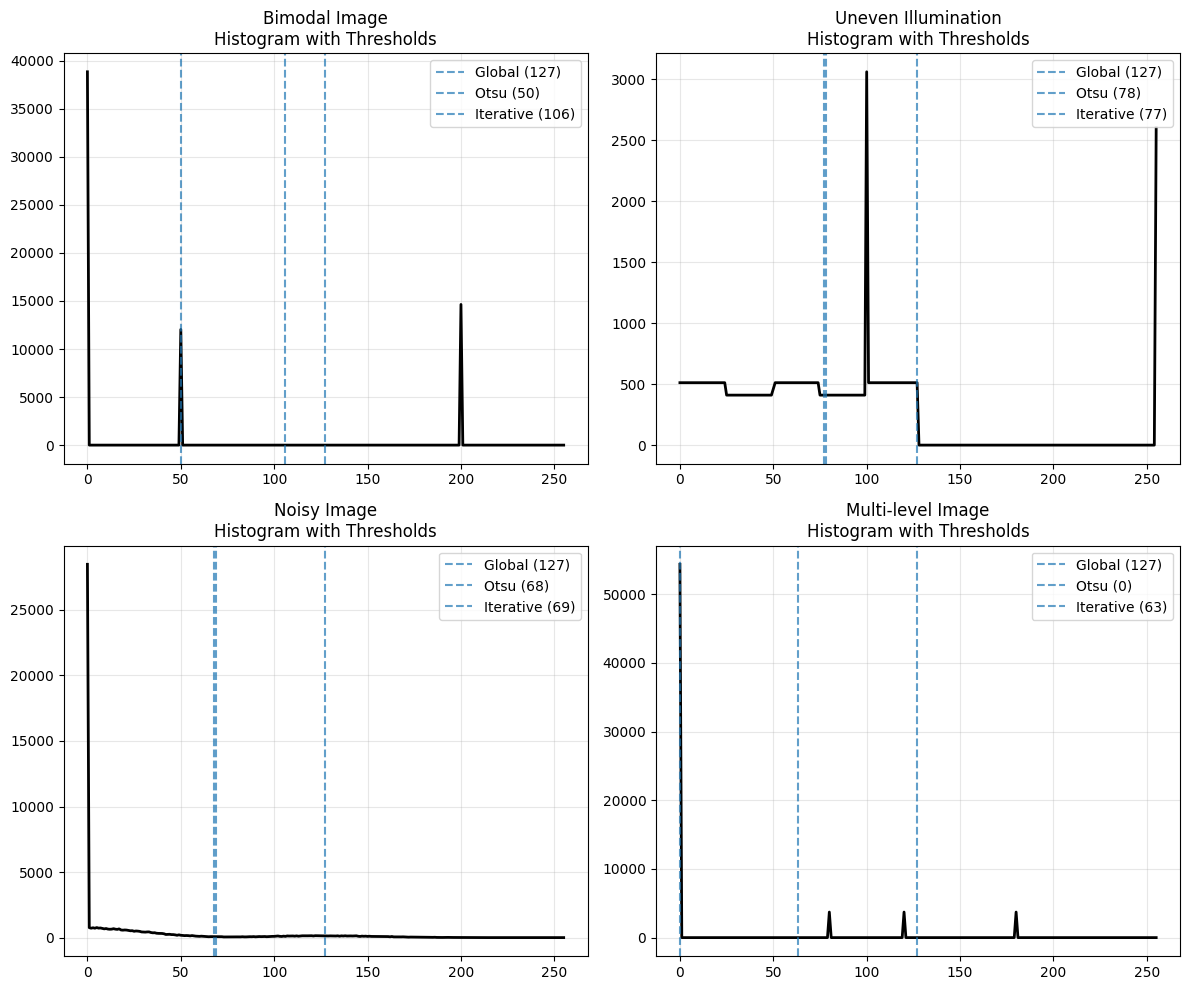


KESIMPULAN DAN REKOMENDASI
----------------------------------------

1. Global Thresholding: sederhana tapi sensitif
2. Otsu: otomatis & bagus untuk bimodal
3. Adaptive: terbaik untuk pencahayaan tidak merata
4. Iterative: fleksibel tapi lebih lambat
    


In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def praktikum_9_1():
    """
    Perbandingan teknik thresholding: Global, Otsu, dan Adaptive
    """
    print("PRAKTIKUM 9.1: PERBANDINGAN TEKNIK THRESHOLDING")
    print("=" * 60)

    # Buat citra test dengan berbagai karakteristik
    def create_test_images():
        images = {}

        img_bimodal = np.zeros((256, 256), dtype=np.uint8)
        cv2.rectangle(img_bimodal, (30, 30), (150, 150), 50, -1)
        cv2.rectangle(img_bimodal, (100, 100), (220, 220), 200, -1)
        images['Bimodal Image'] = img_bimodal

        img_uneven = np.zeros((256, 256), dtype=np.uint8)
        for i in range(256):
            img_uneven[:, i] = i // 2
        cv2.rectangle(img_uneven, (50, 50), (100, 100), 255, -1)
        cv2.rectangle(img_uneven, (150, 150), (200, 200), 100, -1)
        images['Uneven Illumination'] = img_uneven

        img_noisy = np.zeros((256, 256), dtype=np.uint8)
        cv2.rectangle(img_noisy, (50, 50), (150, 150), 128, -1)
        noise = np.random.normal(0, 30, img_noisy.shape)
        img_noisy = np.clip(img_noisy.astype(float) + noise, 0, 255).astype(np.uint8)
        images['Noisy Image'] = img_noisy

        img_multi = np.zeros((256, 256), dtype=np.uint8)
        cv2.rectangle(img_multi, (30, 30), (90, 90), 80, -1)
        cv2.rectangle(img_multi, (100, 30), (160, 90), 120, -1)
        cv2.rectangle(img_multi, (170, 30), (230, 90), 180, -1)
        images['Multi-level Image'] = img_multi

        return images

    def apply_global_threshold(image, T=127):
        _, binary = cv2.threshold(image, T, 255, cv2.THRESH_BINARY)
        return binary

    def apply_otsu_threshold(image):
        """Otsu's thresholding (FIXED)"""
        T, binary = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        return binary, T

    def apply_adaptive_threshold(image, block_size=11, C=2):
        """Adaptive thresholding (improved)"""
        if len(image.shape) == 3:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        # pastikan block size ganjil
        if block_size % 2 == 0:
            block_size += 1

        # tambah blur biar stabil
        image = cv2.GaussianBlur(image, (5,5), 0)

        binary = cv2.adaptiveThreshold(
            image, 255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY,
            block_size, C
        )
        return binary

    def apply_iterative_threshold(image, max_iter=100, tolerance=1):
        T = np.mean(image)

        for i in range(max_iter):
            foreground = image[image > T]
            background = image[image <= T]

            if len(foreground) > 0 and len(background) > 0:
                mu_fg = np.mean(foreground)
                mu_bg = np.mean(background)

                T_new = (mu_fg + mu_bg) / 2

                if abs(T_new - T) < tolerance:
                    T = T_new
                    break

                T = T_new
            else:
                break

        _, binary = cv2.threshold(image, T, 255, cv2.THRESH_BINARY)
        return binary, T

    test_images = create_test_images()

    results = {}

    for name, image in test_images.items():
        if len(image.shape) == 3:
            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        else:
            gray = image.copy()

        global_binary = apply_global_threshold(gray, 127)

        # FIX OTSU
        otsu_binary, T_otsu = apply_otsu_threshold(gray)

        adaptive_binary = apply_adaptive_threshold(gray, 11, 2)
        iterative_binary, T_iter = apply_iterative_threshold(gray)

        results[name] = {
            'original': gray,
            'global': global_binary,
            'otsu': otsu_binary,
            'adaptive': adaptive_binary,
            'iterative': iterative_binary,
            'T_otsu': T_otsu,
            'T_iter': T_iter
        }

    fig, axes = plt.subplots(len(test_images), 5, figsize=(20, 4*len(test_images)))

    for idx, (name, result) in enumerate(results.items()):
        axes[idx, 0].imshow(result['original'], cmap='gray')
        axes[idx, 0].set_title(f'{name}\nOriginal')
        axes[idx, 0].axis('off')

        methods = ['global', 'otsu', 'adaptive', 'iterative']
        titles = [
            'Global (T=127)',
            f'Otsu (T={result["T_otsu"]:.0f})',
            'Adaptive',
            f'Iterative (T={result["T_iter"]:.0f})'
        ]

        for col, (method, title) in enumerate(zip(methods, titles), 1):
            axes[idx, col].imshow(result[method], cmap='gray')
            axes[idx, col].set_title(title)
            axes[idx, col].axis('off')

    plt.tight_layout()
    plt.show()

    print("\nANALISIS HISTOGRAM DAN THRESHOLD SELECTION")
    print("-" * 60)

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.ravel()

    for idx, (name, result) in enumerate(list(results.items())[:4]):
        hist = cv2.calcHist([result['original']], [0], None, [256], [0, 256])
        axes[idx].plot(hist, 'k-', linewidth=2)

        axes[idx].axvline(x=127, linestyle='--', label='Global (127)', alpha=0.7)
        axes[idx].axvline(x=result['T_otsu'], linestyle='--',
                         label=f'Otsu ({result["T_otsu"]:.0f})', alpha=0.7)
        axes[idx].axvline(x=result['T_iter'], linestyle='--',
                         label=f'Iterative ({result["T_iter"]:.0f})', alpha=0.7)

        axes[idx].set_title(f'{name}\nHistogram with Thresholds')
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\nKESIMPULAN DAN REKOMENDASI")
    print("-" * 40)
    print("""
1. Global Thresholding: sederhana tapi sensitif
2. Otsu: otomatis & bagus untuk bimodal
3. Adaptive: terbaik untuk pencahayaan tidak merata
4. Iterative: fleksibel tapi lebih lambat
    """)

    return results

thresholding_results = praktikum_9_1()


PRAKTIKUM 9.2: EDGE DETECTION DAN REGION-BASED SEGMENTATION

EDGE DETECTION RESULTS
----------------------------------------


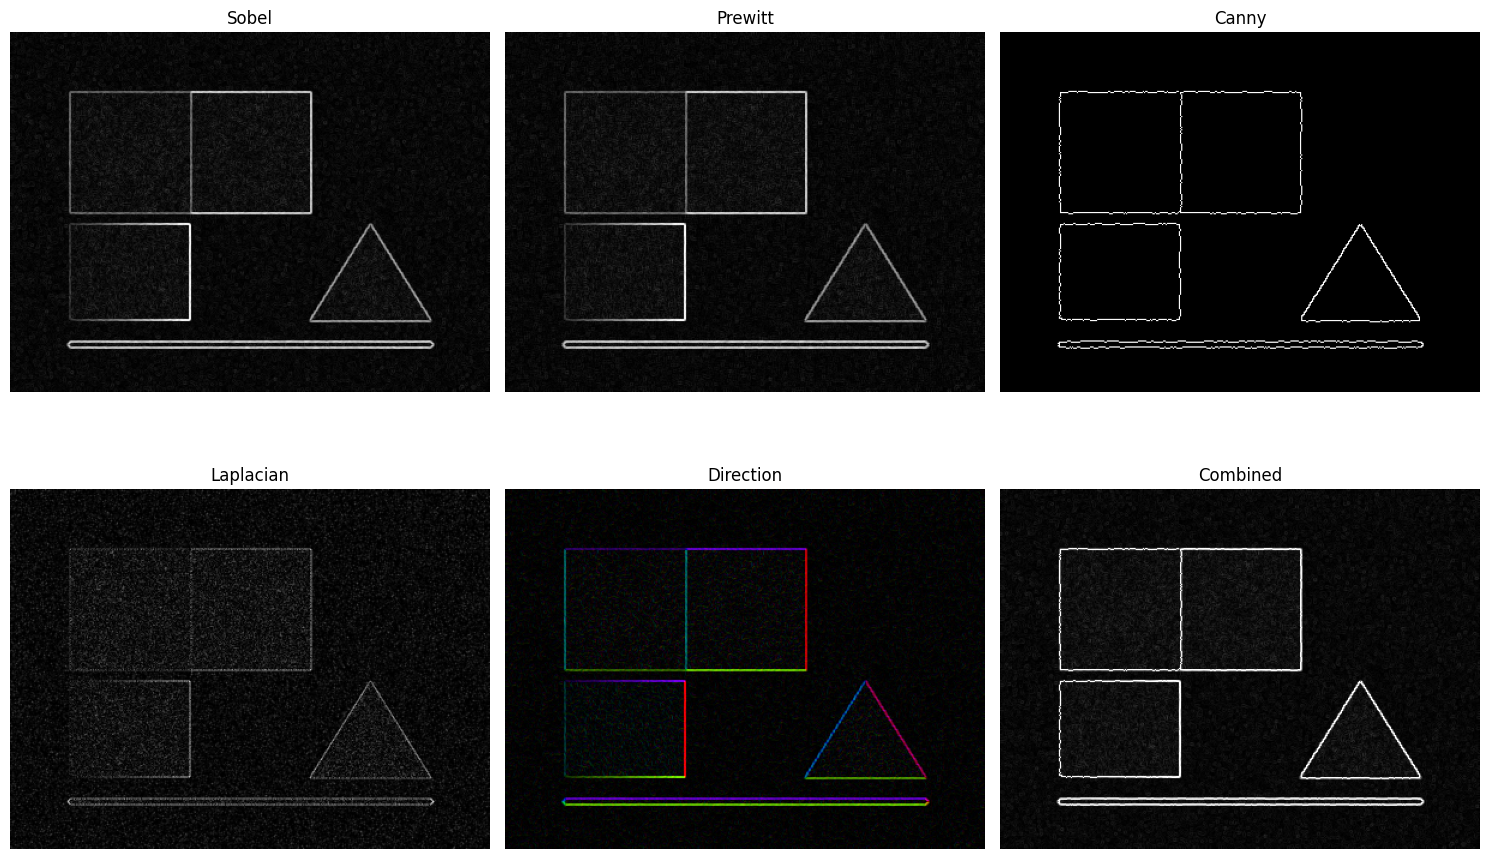


KESIMPULAN
------------------------------

Sobel & Prewitt: deteksi gradien
Canny: paling stabil
Laplacian: sensitif noise
Region Growing: butuh seed
Split-Merge: otomatis
    


In [11]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def praktikum_9_2():
    """
    Implementasi edge detection dan region-based segmentation
    """
    print("\nPRAKTIKUM 9.2: EDGE DETECTION DAN REGION-BASED SEGMENTATION")
    print("=" * 70)

    def create_edge_test_image():
        img = np.zeros((300, 400), dtype=np.uint8)

        cv2.rectangle(img, (50, 50), (150, 150), 100, -1)
        cv2.rectangle(img, (151, 50), (250, 150), 200, -1)

        for i in range(50, 150):
            img[160:240, i] = 50 + (i - 50) * 2

        triangle_cnt = np.array([(300, 160), (350, 240), (250, 240)], dtype=np.int32)
        cv2.drawContours(img, [triangle_cnt], 0, 150, -1)

        cv2.line(img, (50, 260), (350, 260), 200, 3)

        noise = np.random.normal(0, 15, img.shape)
        img = np.clip(img.astype(float) + noise, 0, 255).astype(np.uint8)

        return img

    def apply_sobel_edge_detection(image, ksize=3):
        sobelx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=ksize)
        sobely = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=ksize)

        magnitude = np.sqrt(sobelx**2 + sobely**2)
        magnitude = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX)

        direction = np.arctan2(sobely, sobelx) * 180 / np.pi

        return magnitude.astype(np.uint8), direction

    def apply_prewitt_edge_detection(image):
        kernelx = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]])
        kernely = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])

        prewittx = cv2.filter2D(image.astype(np.float64), -1, kernelx)
        prewitty = cv2.filter2D(image.astype(np.float64), -1, kernely)

        magnitude = np.sqrt(prewittx**2 + prewitty**2)
        magnitude = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX)

        return magnitude.astype(np.uint8)

    def apply_canny_edge_detection(image, low_threshold=50, high_threshold=150):
        blurred = cv2.GaussianBlur(image, (5, 5), 1.4)
        edges = cv2.Canny(blurred, low_threshold, high_threshold)
        return edges

    def apply_laplacian_edge_detection(image):
        laplacian = cv2.Laplacian(image, cv2.CV_64F)
        laplacian = np.abs(laplacian)
        laplacian = cv2.normalize(laplacian, None, 0, 255, cv2.NORM_MINMAX)
        return laplacian.astype(np.uint8)

    def region_growing_segmentation(image, seeds, threshold=20):
        segmented = np.zeros_like(image)
        visited = np.zeros_like(image, dtype=bool)

        if isinstance(seeds, tuple):
            seeds = [seeds]

        for seed in seeds:
            if not (0 <= seed[0] < image.shape[0] and 0 <= seed[1] < image.shape[1]):
                continue

            if visited[seed]:
                continue

            stack = [seed]
            region_pixels = []

            while stack:
                x, y = stack.pop()

                if visited[x, y]:
                    continue

                visited[x, y] = True
                current_value = image[x, y]
                region_pixels.append(current_value)
                segmented[x, y] = 255

                neighbors = [(x-1, y), (x+1, y), (x, y-1), (x, y+1)]
                region_mean = np.mean(region_pixels)

                for nx, ny in neighbors:
                    if (0 <= nx < image.shape[0] and 0 <= ny < image.shape[1]
                        and not visited[nx, ny]):
                        neighbor_value = image[nx, ny]
                        if abs(neighbor_value - region_mean) < threshold:
                            stack.append((nx, ny))

        return segmented

    def region_splitting_merging(image, min_size=32, threshold=20):
        def should_split(region):
            return (np.std(region) > threshold and
                    region.shape[0] > min_size and
                    region.shape[1] > min_size)

        def split_region(region):
            h, w = region.shape
            if h < 2 or w < 2:
                return [region]
            return [
                region[:h//2, :w//2],
                region[:h//2, w//2:],
                region[h//2:, :w//2],
                region[h//2:, w//2:]
            ]

        def merge_regions(regions):
            merged = []
            used = [False] * len(regions)

            for i, region in enumerate(regions):
                if used[i]:
                    continue

                current_region = region
                used[i] = True

                for j, other_region in enumerate(regions[i+1:], i+1):
                    if used[j]:
                        continue

                    if (abs(np.mean(current_region) - np.mean(other_region)) < threshold and
                        abs(np.std(current_region) - np.std(other_region)) < threshold/2):

                        h1, w1 = current_region.shape
                        h2, w2 = other_region.shape
                        h_max = max(h1, h2)
                        w_max = max(w1, w2)

                        merged_region = np.zeros((h_max, w_max))
                        merged_region[:h1, :w1] = current_region
                        merged_region[:h2, :w2] = np.maximum(
                            merged_region[:h2, :w2], other_region
                        )

                        current_region = merged_region
                        used[j] = True

                merged.append(current_region)

            return merged

        regions = [image]

        splitting = True
        while splitting:
            splitting = False
            new_regions = []

            for region in regions:
                if should_split(region):
                    new_regions.extend(split_region(region))
                    splitting = True
                else:
                    new_regions.append(region)

            regions = new_regions

        regions = merge_regions(regions)

        result = np.zeros_like(image)
        current_value = 50

        for region in regions:
            h, w = region.shape
            result[:h, :w] = current_value
            current_value = min(current_value + 50, 255)

        return result

    test_image = create_edge_test_image()

    edge_results = {}

    sobel_magnitude, sobel_direction = apply_sobel_edge_detection(test_image)
    edge_results['Sobel'] = sobel_magnitude

    edge_results['Prewitt'] = apply_prewitt_edge_detection(test_image)
    edge_results['Canny'] = apply_canny_edge_detection(test_image)
    edge_results['Laplacian'] = apply_laplacian_edge_detection(test_image)

    seeds = [(75, 100), (200, 100), (299, 200)]

    region_results = {}
    region_results['Region Growing'] = region_growing_segmentation(test_image, seeds, threshold=25)
    region_results['Split & Merge'] = region_splitting_merging(test_image)

    print("\nEDGE DETECTION RESULTS")
    print("-" * 40)

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    axes[0, 0].imshow(test_image, cmap='gray')
    axes[0, 0].set_title('Test Image')
    axes[0, 0].axis('off')

    for idx, method in enumerate(['Sobel', 'Prewitt', 'Canny'], 1):
        axes[0, idx-1].imshow(edge_results[method], cmap='gray')
        axes[0, idx-1].set_title(method)
        axes[0, idx-1].axis('off')

    axes[1, 0].imshow(edge_results['Laplacian'], cmap='gray')
    axes[1, 0].set_title('Laplacian')
    axes[1, 0].axis('off')

    hsv = np.zeros((test_image.shape[0], test_image.shape[1], 3), dtype=np.uint8)
    hsv[..., 0] = np.clip(((sobel_direction + 180) / 2), 0, 255).astype(np.uint8)
    hsv[..., 1] = 255
    hsv[..., 2] = sobel_magnitude

    axes[1, 1].imshow(cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB))
    axes[1, 1].set_title('Direction')
    axes[1, 1].axis('off')

    combined_edges = np.zeros_like(test_image, dtype=np.float32)
    for method in ['Sobel', 'Canny']:
        combined_edges = np.maximum(combined_edges, edge_results[method].astype(np.float32))

    combined_edges = cv2.normalize(combined_edges, None, 0, 255, cv2.NORM_MINMAX)

    axes[1, 2].imshow(combined_edges.astype(np.uint8), cmap='gray')
    axes[1, 2].set_title('Combined')
    axes[1, 2].axis('off')

    plt.tight_layout()
    plt.show()

    print("\nKESIMPULAN")
    print("-" * 30)
    print("""
Sobel & Prewitt: deteksi gradien
Canny: paling stabil
Laplacian: sensitif noise
Region Growing: butuh seed
Split-Merge: otomatis
    """)

    return test_image, edge_results, region_results

edge_test_image, edge_results, region_results = praktikum_9_2()